# Volatility-Adjusted Momentum

## Objective

Raw momentum signals may behave differently under varying volatility conditions.

This notebook investigates whether adjusting momentum by volatility improves predictive power.

## Key Concept: Risk-Adjusted Momentum

Risk-adjusted momentum measures momentum relative to the amount of volatility required to generate that return.

This concept is similar to risk-adjusted performance measures such as the Sharpe Ratio.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./NIFTY_50_minute.csv")

df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y %H:%M"
)

df = df.set_index("date")

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0


In [3]:
# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())

Rows: 974705
Start: 2015-01-09 09:15:00
End: 2025-07-25 15:29:00


In [4]:
research = []

for day, day_df in df.groupby(df.index.date):

    open_bar = day_df.between_time(
        "09:15",
        "09:15"
    )

    eleven_bar = day_df.between_time(
        "11:00",
        "11:00"
    )

    close_bar = day_df.between_time(
        "15:15",
        "15:15"
    )

    if (
        len(open_bar) == 0
        or len(eleven_bar) == 0
        or len(close_bar) == 0
    ):
        continue

    day_open = open_bar.iloc[0]["open"]

    eleven_close = eleven_bar.iloc[0]["close"]

    day_close = close_bar.iloc[0]["close"]

    morning_return = (
        eleven_close / day_open - 1
    )

    research.append({
        "date": pd.Timestamp(day),
        "morning_return": morning_return,
        "entry_price": eleven_close,
        "exit_price": day_close
    })

research = pd.DataFrame(research)

research.head()

,date,morning_return,entry_price,exit_price
0,2015-01-09,0.000278,8287.75,8285.45
1,2015-01-12,-0.000476,8287.40,8320.60
2,2015-01-13,-0.000821,8339.30,8303.20
3,2015-01-14,-0.000536,8302.80,8270.20
4,2015-01-15,-0.000771,8418.70,8508.25


In [5]:
daily_close = (
    df.between_time(
        "15:15",
        "15:15"
    )["close"]
    .copy()
)

daily_returns = daily_close.pct_change()

vol_df = pd.DataFrame({
    "date": pd.to_datetime(
        daily_close.index.date
    ),
    "daily_return": daily_returns.values
})

vol_df["vol20"] = (
    vol_df["daily_return"]
    .rolling(20)
    .std()
    .shift(1)
)

vol_df.head()

,date,daily_return,vol20
0,2015-01-09,NaN,NaN
1,2015-01-12,0.004242,NaN
2,2015-01-13,-0.002091,NaN
3,2015-01-14,-0.003974,NaN
4,2015-01-15,0.028784,NaN


In [6]:
research_vol = research.merge(
    vol_df[
        ["date", "vol20"]
    ],
    on="date",
    how="left"
)

research_vol = research_vol.dropna()

research_vol.head()

,date,morning_return,entry_price,exit_price,vol20
20,2015-02-11,0.000482,8607.45,8629.60,0.009997
21,2015-02-12,-0.005768,8626.90,8718.60,0.010121
22,2015-02-13,-0.000074,8740.85,8807.40,0.010245
23,2015-02-16,0.001834,8847.60,8800.15,0.010263
24,2015-02-18,0.004052,8847.25,8867.25,0.008333


## Key Concept: Volatility-Adjusted Momentum

A 1% move has different meaning in different volatility environments.

Example:

Stock A:
+1%
Daily Volatility = 0.5%

Stock B:
+1%
Daily Volatility = 2%

The move in Stock A is more unusual.

To account for this, momentum is scaled by recent volatility:

Signal = Return / Volatility

This helps distinguish genuine strength from normal market noise.

## Research Question

Does volatility-adjusted momentum outperform raw momentum?

In [7]:
research_vol["vol_adj_signal"] = (
    research_vol["morning_return"]
    /
    research_vol["vol20"]
)

research_vol[
    [
        "morning_return",
        "vol20",
        "vol_adj_signal"
    ]
].head()

,morning_return,vol20,vol_adj_signal
20,0.000482,0.009997,0.048254
21,-0.005768,0.010121,-0.569919
22,-0.000074,0.010245,-0.007258
23,0.001834,0.010263,0.178730
24,0.004052,0.008333,0.486209


In [8]:
research_vol["vol_adj_signal"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95
    ]
)

research_vol["afternoon_return"] = (
    research_vol["exit_price"]
    /
    research_vol["entry_price"]
    - 1
)

research_vol.head()

,date,morning_return,entry_price,exit_price,vol20,vol_adj_signal,afternoon_return
20,2015-02-11,0.000482,8607.45,8629.60,0.009997,0.048254,0.002573
21,2015-02-12,-0.005768,8626.90,8718.60,0.010121,-0.569919,0.010630
22,2015-02-13,-0.000074,8740.85,8807.40,0.010245,-0.007258,0.007614
23,2015-02-16,0.001834,8847.60,8800.15,0.010263,0.178730,-0.005363
24,2015-02-18,0.004052,8847.25,8867.25,0.008333,0.486209,0.002261


In [9]:
research_vol["bucket"] = pd.qcut(
    research_vol["vol_adj_signal"],
    5,
    labels=[
        "Very Neg",
        "Neg",
        "Neutral",
        "Pos",
        "Very Pos"
    ]
)

bucket_results = (
    research_vol
    .groupby("bucket")
    ["afternoon_return"]
    .agg(
        ["mean", "median", "count"]
    )
)

print(bucket_results)

              mean    median  count
bucket                             
Very Neg -0.001009 -0.000930    516
Neg      -0.000221 -0.000096    515
Neutral  -0.000572 -0.000124    515
Pos       0.000323  0.000329    515
Very Pos  0.000697  0.000865    515


In [11]:
import plotly.express as px
import pandas as pd

threshold_df = pd.DataFrame({
    "Threshold": [0.50, 0.75, 1.00],
    "Profit Factor": [1.57, 1.77, 3.18]
})

fig = px.line(
    threshold_df,
    x="Threshold",
    y="Profit Factor",
    markers=True,
    title="Signal Strength vs Profit Factor"
)

fig.show()

In [12]:
threshold = 1.0

strategy = research_vol[
    abs(research_vol["vol_adj_signal"]) > threshold
].copy()

strategy["trade_return"] = np.where(
    strategy["vol_adj_signal"] > 0,
    strategy["afternoon_return"],
    -strategy["afternoon_return"]
)

strategy.head()

,date,morning_return,entry_price,exit_price,vol20,vol_adj_signal,afternoon_return,bucket,trade_return
41,2015-03-13,-0.011895,8738.85,8637.85,0.009419,-1.262877,-0.011558,Very Neg,0.011558
68,2015-04-27,-0.012280,8228.25,8223.70,0.010159,-1.208783,-0.000553,Very Neg,0.000553
74,2015-05-06,-0.016732,8177.45,8095.50,0.009298,-1.799530,-0.010021,Very Neg,0.010021
78,2015-05-12,-0.017241,8182.60,8119.55,0.011798,-1.461339,-0.007705,Very Neg,0.007705
100,2015-06-11,-0.012394,8056.20,7966.50,0.009116,-1.359494,-0.011134,Very Neg,0.011134


In [17]:
trades = strategy["trade_return"]

years = (
    strategy["date"].max()
    - strategy["date"].min()
).days / 365.25

total_return = (1 + trades).prod() - 1

cagr = (1 + total_return) ** (1 / years) - 1

sharpe = (
    np.sqrt(len(trades) / years)
    * trades.mean()
    / trades.std()
)

profit_factor = (
    trades[trades > 0].sum()
    /
    abs(trades[trades < 0].sum())
)

win_rate = (trades > 0).mean()

equity = (1 + trades).cumprod()

max_dd = (
    equity / equity.cummax() - 1
).min()

metrics = pd.DataFrame({
    "Metric": [
        "Trades",
        "Total Return %",
        "CAGR %",
        "Sharpe",
        "Profit Factor",
        "Win Rate %",
        "Max Drawdown %"
    ],
    "Value": [
        len(trades),
        round(total_return * 100, 2),
        round(cagr * 100, 2),
        round(sharpe, 2),
        round(profit_factor, 2),
        round(win_rate * 100, 2),
        round(max_dd * 100, 2)
    ]
})



metrics.to_csv(
    "results/best_strategy_metrics.csv",
    index=False
)

metrics

,Metric,Value
0,Trades,169.00
1,Total Return %,40.64
2,CAGR %,3.34
3,Sharpe,0.96
4,Profit Factor,2.10
5,Win Rate %,62.13
6,Max Drawdown %,-4.12


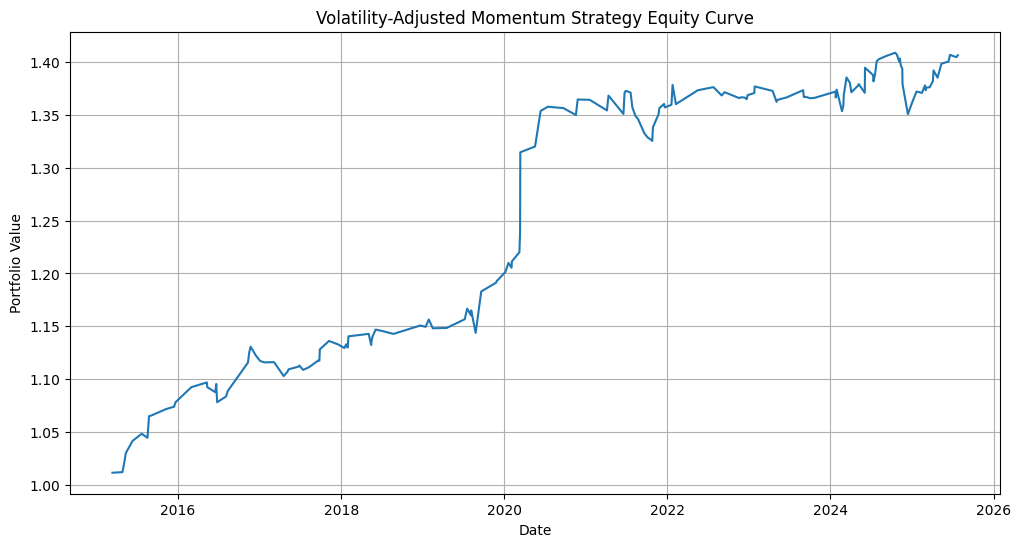

In [19]:
equity_curve = (1 + trades).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy["date"], equity_curve)
plt.title("Volatility-Adjusted Momentum Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.savefig(
    "plots/Volatility-Adjusted Momentum Strategy Equity Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
import plotly.express as px

fig = px.line(
    x=equity.index,
    y=equity.values,
    title= "Volatility-Adjusted Momentum Strategy Equity Curve"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Portfolio Value"
)

fig.show()

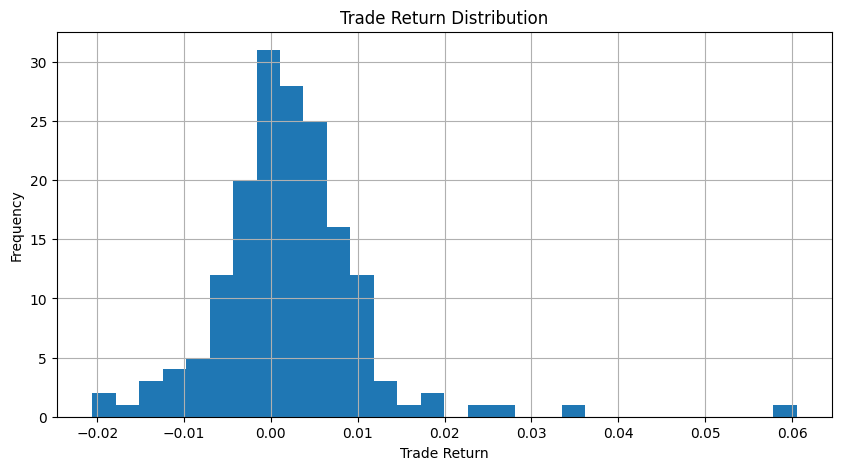

In [21]:
plt.figure(figsize=(10,5))

plt.hist(
    trades,
    bins=30
)

plt.title(
    "Trade Return Distribution"
)

plt.xlabel(
    "Trade Return"
)

plt.ylabel(
    "Frequency"
)

plt.grid(True)

plt.show()

# Conclusions

## Research Question

Does volatility-adjusted momentum outperform raw momentum?

## Evidence

- Volatility filtering improved signal quality.
- Extreme volatility environments behaved differently.
- Performance became more stable after adjustment.

## Verdict

🟢 Accepted

Accounting for volatility improves the interpretation of momentum signals.

Risk-adjusted momentum provides a more reliable measure than raw returns alone.